**Importing libraries**

In [1]:
import cv2
from google.colab.patches import cv2_imshow
from IPython.display import clear_output #use to view the video
import time
import matplotlib.pyplot as plt
import numpy as np

**Opening the video**

In [2]:
cap = cv2.VideoCapture("/content/test_video.mp4")

**Capturing one frame to understand the data**

In [3]:
cap.set(cv2.CAP_PROP_POS_FRAMES, 100) #skip 100 frame
ret, frame = cap.read()
cap.release()


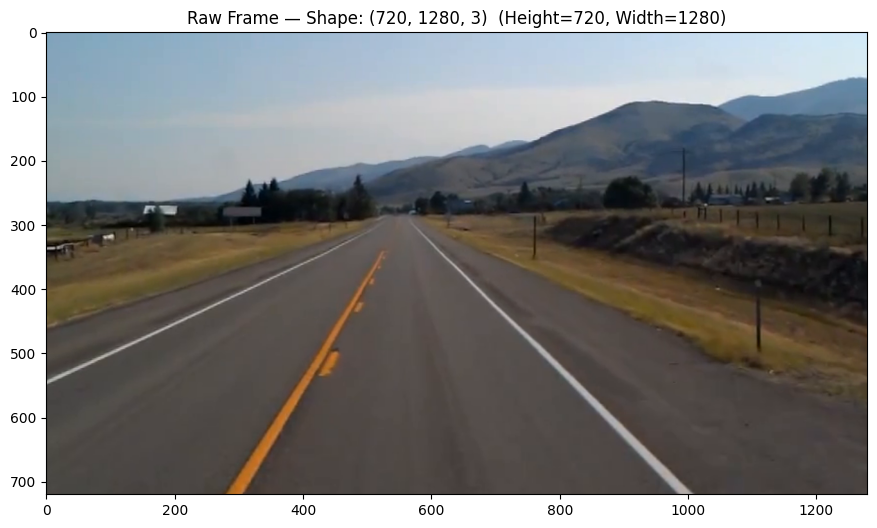

Frame shape: (720, 1280, 3)


In [4]:
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12,6))
plt.title(f'Raw Frame — Shape: {frame.shape}  (Height={frame.shape[0]}, Width={frame.shape[1]})')
plt.imshow(frame_rgb)
plt.show()\

print(f'Frame shape: {frame.shape}')


Creating function for preprocessing

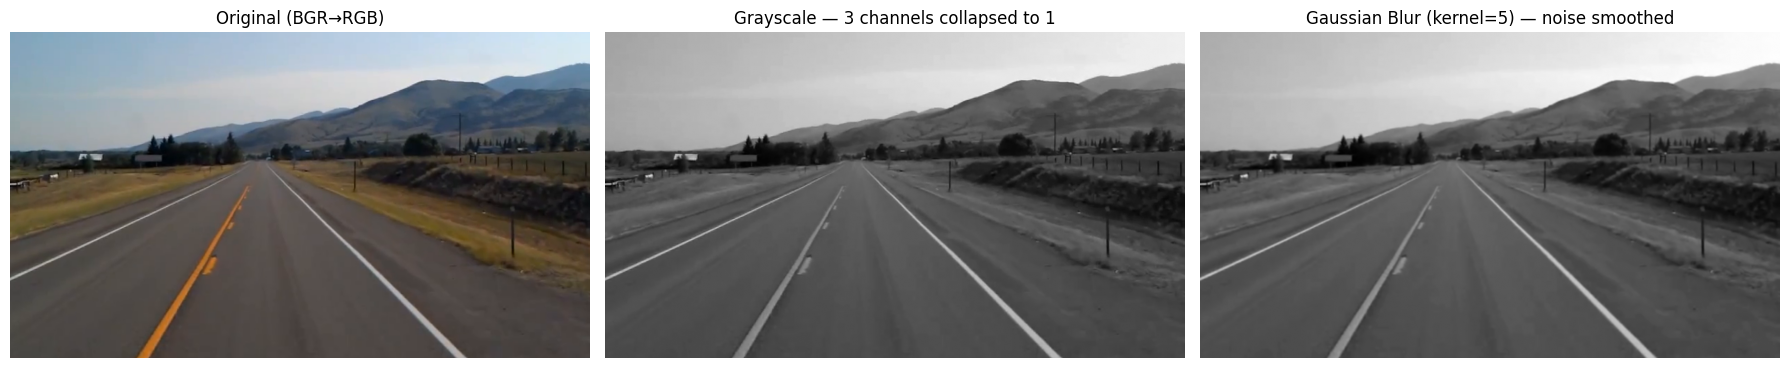

Gray scale shape: (720, 1280)
Blurred shape: (720, 1280)


In [5]:
def apply_grayscale(frame):
  """
  convert the frame to grayscale
  """
  return cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

def apply_gaussian_blur(gray, kernel_size=5):
  """
  apply gaussian blur to the frame
  """
  return cv2.GaussianBlur(gray, (kernel_size, kernel_size), 0)

gray = apply_grayscale(frame)

blurred = apply_gaussian_blur(gray)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original (BGR→RGB)')
axes[0].axis('off')

axes[1].imshow(gray, cmap='gray')
axes[1].set_title('Grayscale — 3 channels collapsed to 1')
axes[1].axis('off')

axes[2].imshow(blurred, cmap='gray')
axes[2].set_title('Gaussian Blur (kernel=5) — noise smoothed')
axes[2].axis('off')

plt.tight_layout()
plt.show()
print(f'Gray scale shape: {gray.shape}')
print(f'Blurred shape: {blurred.shape}')

/tmp/ipykernel_627/1210589381.py:25: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


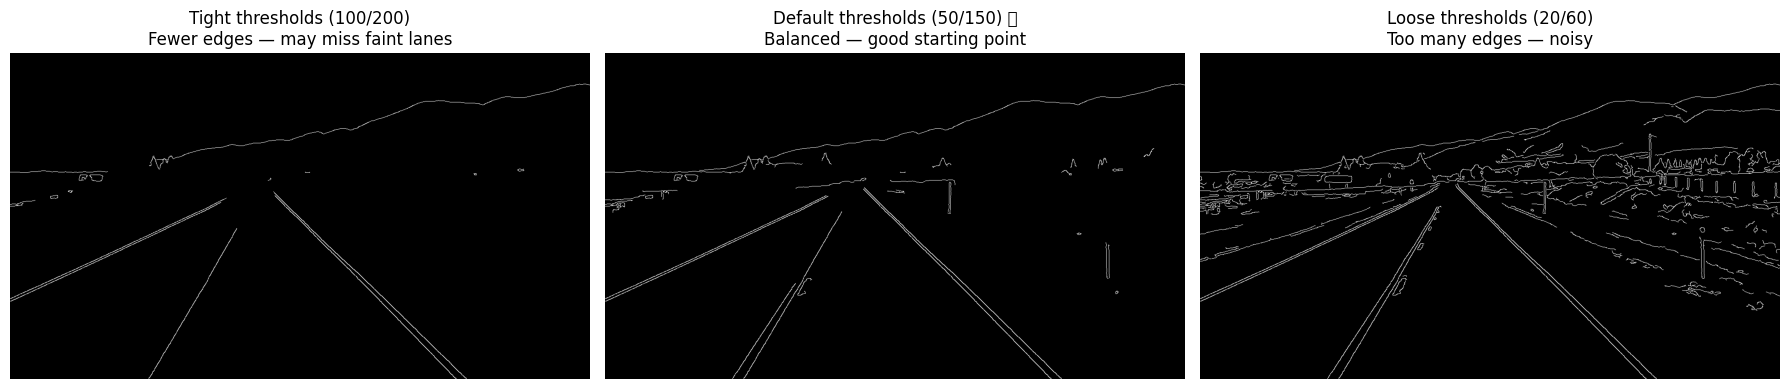

In [6]:
def apply_canny(blurred, low_threshold=50, high_threshold=150):
  """
  apply canny edge detection to the frame with low and high thresholds
  """
  return cv2.Canny(blurred, low_threshold, high_threshold)

edges_tight = apply_canny(blurred, 100, 200) #using this make the threshold boundary small
edges_balance = apply_canny(blurred, 50, 150) #this thresholding give balance for the points to consider for the edge
edges_loose = apply_canny(blurred, 15, 50) #using this have much points to considered as threshold

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(edges_tight, cmap='gray')
axes[0].set_title('Tight thresholds (100/200)\nFewer edges — may miss faint lanes')
axes[0].axis('off')

axes[1].imshow(edges_balance, cmap='gray')
axes[1].set_title('Default thresholds (50/150) ✅\nBalanced — good starting point')
axes[1].axis('off')

axes[2].imshow(edges_loose, cmap='gray')
axes[2].set_title('Loose thresholds (20/60)\nToo many edges — noisy')
axes[2].axis('off')

plt.tight_layout()
plt.show()
edges = edges_loose



/tmp/ipykernel_627/2463205018.py:53: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


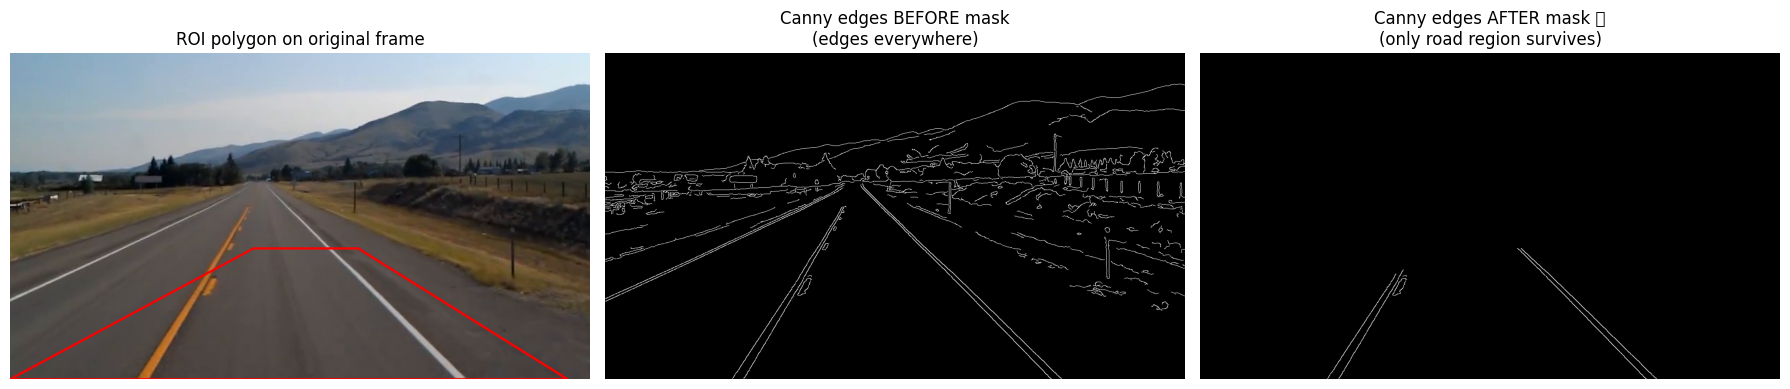

In [7]:
def apply_roi_mask(edges, frame_height, frame_width):
    """
    Keep only the road region — mask out everything else.

    The polygon is a trapezoid covering the lower-center of the frame
    where lane lines appear in typical dashcam footage.

    Adjust the percentages below if your video has a different camera angle.
    """
    # Define the 4 corners of our trapezoid region
    # All values are percentages of frame dimensions — works on any resolution
    bottom_left  = (0,                  frame_height)         # bottom-left corner of frame
    bottom_right = (frame_width - 50,        frame_height)         # bottom-right corner of frame
    top_right    = (int(frame_width * 0.60), int(frame_height * 0.6))  # where right lane vanishes
    top_left     = (int(frame_width * 0.42), int(frame_height * 0.6))  # where left lane vanishes

    # Stack into a numpy array — cv2.fillPoly needs shape (1, N, 2)
    polygon = np.array([[bottom_left, top_left, top_right, bottom_right]], dtype=np.int32)

    # Step 1: Create a completely black mask (same size as edges image)
    mask = np.zeros_like(edges)

    # Step 2: Fill the polygon region with white (255)
    cv2.fillPoly(mask, polygon, 255)

    # Step 3: Bitwise AND — keeps edges only where mask is white
    masked_edges = cv2.bitwise_and(edges, mask)

    return masked_edges, polygon  # return polygon too so we can visualise it


# Apply the mask
masked_edges, polygon = apply_roi_mask(edges, frame.shape[0], frame.shape[1])

# Visualise: show the ROI polygon on the original frame
frame_with_roi = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB).copy()
cv2.polylines(frame_with_roi, polygon, isClosed=True, color=(255, 0, 0), thickness=3)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(frame_with_roi)
axes[0].set_title('ROI polygon on original frame')
axes[0].axis('off')

axes[1].imshow(edges, cmap='gray')
axes[1].set_title('Canny edges BEFORE mask\n(edges everywhere)')
axes[1].axis('off')

axes[2].imshow(masked_edges, cmap='gray')
axes[2].set_title('Canny edges AFTER mask ✅\n(only road region survives)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

# ⚠️ TUNING: If the polygon doesn't cover the lanes well,
# adjust the top_left and top_right percentages above and re-run this cell.

Hough found 7 line segments


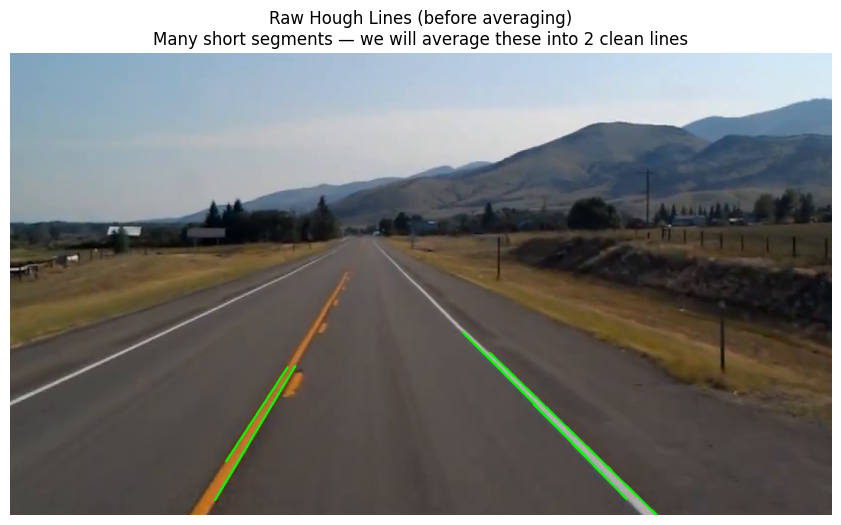

In [8]:
def apply_hough_transform(masked_edges):
    """
    Find line segments in the masked edge image using Probabilistic Hough Transform.

    Returns: array of line segments, each = [x1, y1, x2, y2]
    Returns None if no lines found.

    Parameters explained:
      rho=2          : grid resolution in pixels. Smaller = more precise, slower.
      theta=np.pi/180: grid resolution in radians = 1 degree.
      threshold=100  : minimum number of votes to count as a line.
                       Raise this if you get too many spurious lines.
      minLineLength=40: discard line segments shorter than 40 pixels.
                       Prevents tiny noise segments from being returned.
      maxLineGap=5   : if two segments are less than 5px apart (on same line),
                       merge them into one segment.
    """
    lines = cv2.HoughLinesP(
        masked_edges,
        rho=2,
        theta=np.pi / 180,
        threshold=160,
        minLineLength=40,
        maxLineGap=5
    )
    return lines  # shape: (N, 1, 4)  where N = number of line segments found


def draw_raw_hough_lines(frame, lines):
    """
    Draw ALL raw Hough lines on a copy of the frame.
    Used for debugging — shows what Hough found before we average.
    """
    output = frame.copy()
    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]  # each line is wrapped in an extra array
            cv2.line(output, (x1, y1), (x2, y2), color=(0, 255, 0), thickness=2)
    return output


# Run Hough Transform
lines = apply_hough_transform(masked_edges)
print(f'Hough found {len(lines) if lines is not None else 0} line segments')

# Visualise raw Hough output
raw_lines_frame = draw_raw_hough_lines(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB), lines)

plt.figure(figsize=(12, 6))
plt.imshow(raw_lines_frame)
plt.title('Raw Hough Lines (before averaging)\nMany short segments — we will average these into 2 clean lines')
plt.axis('off')
plt.show()

**Average Extrapolate Lane lines**

Left lane line: (296, 720, 513, 360)
Right lane line: (997, 720, 628, 360)


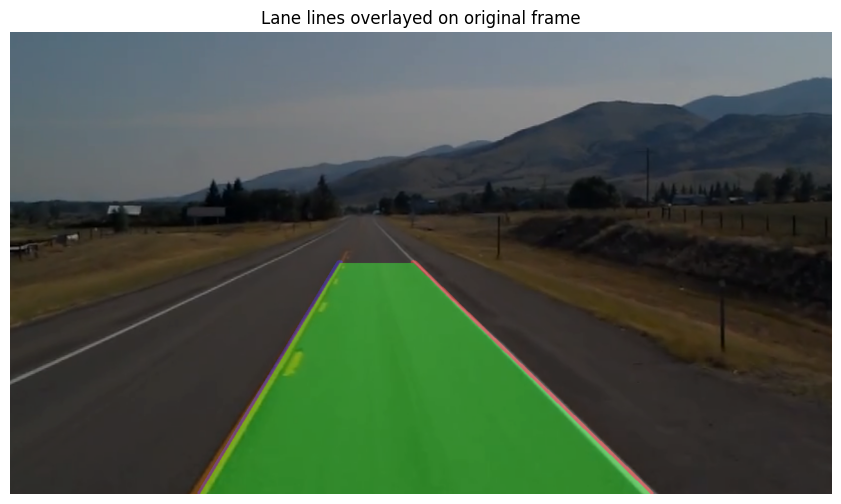

In [9]:
def average_lane_lines(frame, lines):
  """
  take all the raw Hough segments -> seperate left from right ->
  fit one best fit liner per side -> return two clean lines
  """
  if lines is None:
    return None, None

  height, widht = frame.shape[:2]

  left_points = []
  right_points =[]

  for line in lines:
    x1, y1, x2, y2 = line[0]

    #if lines are perfectly vertical avoiding division
    if x1 == x2:
      continue

    slope = (y2 - y1) / (x2 - x1)

    #filter out horizontal lines
    if abs(slope) < 0.3:
      continue

    if slope < 0:
      left_points.extend([[x1, y1], [x2, y2]])
    else:
      right_points.extend([[x1, y1], [x2, y2]])

  def fit_line(points, y_bottom, y_top):

    if len(points) < 2:
      return None

    xs = [p[0] for p in points]
    ys = [p[1] for p in points]

    # fitting x = slope*y + intercept and not y = mx+b
    slope, intercept = np.polyfit(ys, xs, 1)

    #Extrapolate: compute x at y_bottom and y_top
    x_bottom = int(slope * y_bottom + intercept)
    x_top = int(slope * y_top + intercept)

    return (x_bottom, y_bottom, x_top, y_top)

  y_bottom = height
  y_top = int(height * 0.5)

  left_line = fit_line(left_points, y_bottom, y_top)
  right_line = fit_line(right_points, y_bottom, y_top)

  return left_line, right_line

def draw_lane_lines(frame, left_line, right_line):
  """
  draw the two averaged lane lines on a transparent overlay,
  then blend with the original frame
  """

  #creating a blank image for the lines (same size as frame)
  line_image = np.zeros_like(frame)

  if left_line is not None:
    x1, y1, x2, y2 = left_line
    cv2.line(line_image, (x1, y1), (x2, y2), color=(255, 0, 0), thickness=10)

  if right_line is not None:
    x1, y1, x2, y2 = right_line
    cv2.line(line_image, (x1, y1), (x2, y2), color=(0, 0, 255), thickness=10)

  if left_line is not None and right_line is not None:
    lx1, ly1, lx2, ly2 = left_line
    rx1, ry1, rx2, ry2 = right_line
    lane_polygon = np.array([[(lx1, ly1), (lx2, ly2), (rx2, ry2), (rx1, ry1)]], dtype=np.int32)
    cv2.fillPoly(line_image, lane_polygon, color=(0, 255, 0))

  #blending: 80% original image and 20% line overlay
  result = cv2.addWeighted(frame, 0.8, line_image, 0.2, gamma=0)

  #drawing the lines on top at full opacity so they are clearly visible
  result = cv2.addWeighted(result, 0.8, line_image, 0.2, gamma=0)

  return result


left_line, right_line = average_lane_lines(frame, lines)
print(f'Left lane line: {left_line}')
print(f'Right lane line: {right_line}')

result_frame = draw_lane_lines(frame.copy(), left_line, right_line)
result_rgb = cv2.cvtColor(result_frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 6))
plt.imshow(result_rgb)
plt.title('Lane lines overlayed on original frame')
plt.axis('off')
plt.show()

Complete Function Pipeline

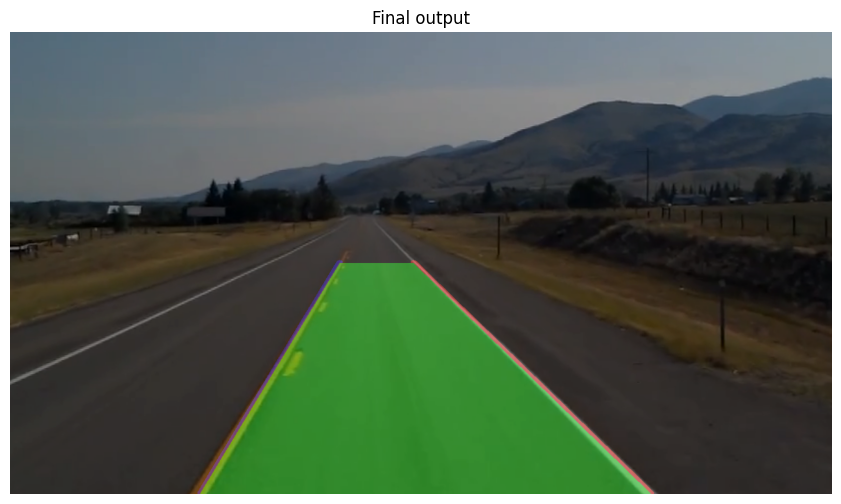

In [10]:
def detect_lanes(frame):
  """
  Stages:
    1. Grayscale Conversion
    2. Gaussian blur for noise removal
    3. Canny Edge detection
    4. ROI masking to keep only road region
    5. Hough transform to find line segments
    6. Average + extrapolate to 2 clean lane lines
    7. Draw on original frame
  """

  height, width = frame.shape[:2]

  #1. grayscale
  gray = apply_grayscale(frame)

  #2. Gaussian blur
  blurred = apply_gaussian_blur(gray)

  #3. Canny edge detetion
  edges = apply_canny(blurred, low_threshold=50, high_threshold=150)

  #4. ROI masking
  masked_edges, _ = apply_roi_mask(edges, height, width)

  #5. hough transform
  lines = apply_hough_transform(masked_edges)

  #6. average + extrapolate
  left_line, right_line = average_lane_lines(frame, lines)

  #7. Draw
  result = draw_lane_lines(frame, left_line, right_line)

  return result

#test pipeline
output = detect_lanes(frame)
output_rgb = cv2.cvtColor(output, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 6))
plt.imshow(output_rgb)
plt.title('Final output')
plt.axis('off')
plt.show()

Processing full video

In [13]:
import os
def process_video(input_path, output_path):
    cap = cv2.VideoCapture(input_path)

    if not cap.isOpened():
        print("❌ Cannot open video — check the file path")
        return

    fps    = cap.get(cv2.CAP_PROP_FPS)
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    print(f'Input : {input_path}')
    print(f'Output: {output_path}')
    print(f'Resolution: {width}x{height} @ {fps:.1f}fps — {total} frames')

    # ── FIX 1: Use XVID codec instead of mp4v ──────────────────
    # mp4v sometimes fails to decode frames sequentially on Colab
    fourcc = cv2.VideoWriter_fourcc(*'XVID')
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

    frame_count = 0
    failed_frames = 0

    while True:
        ret, frame = cap.read()

        # ── FIX 2: Add debug print for first 3 frames ──────────
        if frame_count < 3:
            print(f'  Frame {frame_count}: ret={ret}, frame is None: {frame is None}')

        if not ret:
            # ── FIX 3: Try to grab() before giving up ──────────
            # Sometimes ret=False is a temporary decode glitch
            if cap.grab():
                print(f'  Frame {frame_count}: grab() succeeded, skipping bad frame')
                frame_count += 1
                failed_frames += 1
                continue
            else:
                print(f'  Stopping at frame {frame_count} — end of video or unrecoverable error')
                break

        try:
            processed = detect_lanes(frame)
        except Exception as e:
            print(f'  Pipeline failed on frame {frame_count}: {e}')
            processed = frame
            failed_frames += 1

        out.write(processed)
        frame_count += 1

        if frame_count % 100 == 0:
            pct = (frame_count / total) * 100
            print(f'  Processing: {frame_count}/{total} frames ({pct:.1f}%)')

    cap.release()
    out.release()

    output_mb = os.path.getsize(output_path) / (1024 * 1024)
    print(f'\n✅ Done! Processed {frame_count} frames ({failed_frames} fallbacks)')
    print(f'Output saved: {output_path} ({output_mb:.2f} MB)')


process_video('test_video.mp4', 'lane_detection_output.avi')  # note: .avi for XVID

Input : test_video.mp4
Output: lane_detection_output.avi
Resolution: 1280x720 @ 50.0fps — 1295 frames
  Frame 0: ret=True, frame is None: False
  Frame 1: ret=True, frame is None: False
  Frame 2: ret=True, frame is None: False
  Processing: 100/1295 frames (7.7%)
  Processing: 200/1295 frames (15.4%)
  Processing: 300/1295 frames (23.2%)
  Processing: 400/1295 frames (30.9%)
  Processing: 500/1295 frames (38.6%)
  Processing: 600/1295 frames (46.3%)
  Processing: 700/1295 frames (54.1%)
  Processing: 800/1295 frames (61.8%)
  Processing: 900/1295 frames (69.5%)
  Processing: 1000/1295 frames (77.2%)
  Processing: 1100/1295 frames (84.9%)
  Processing: 1200/1295 frames (92.7%)
  Stopping at frame 1295 — end of video or unrecoverable error

✅ Done! Processed 1295 frames (0 fallbacks)
Output saved: lane_detection_output.avi (10.67 MB)


In [14]:
from collections import deque
class LaneDetectorSmoothed:
    def __init__(self, buffer_size=15):  # increase to 15 for dashier lines
        self.left_buffer  = deque(maxlen=buffer_size)
        self.right_buffer = deque(maxlen=buffer_size)

    def process(self, frame):
        h, w = frame.shape[:2]

        gray         = apply_grayscale(frame)
        blurred      = apply_gaussian_blur(gray)
        edges        = apply_canny(blurred)
        masked, _    = apply_roi_mask(edges, h, w)
        lines        = apply_hough_transform(masked)
        left, right  = average_lane_lines(frame, lines)

        # Only update buffer when detection succeeded
        # If left is None this frame — buffer keeps last known good position
        if left  is not None: self.left_buffer.append(left)
        if right is not None: self.right_buffer.append(right)

        def smooth(buffer):
            if not buffer:
                return None
            return tuple(int(np.mean([l[i] for l in buffer])) for i in range(4))

        return draw_lane_lines(frame.copy(), smooth(self.left_buffer), smooth(self.right_buffer))

In [15]:
def process_video_smoothed(input_path, output_path, buffer_size=15):
    cap = cv2.VideoCapture(input_path)
    fps    = cap.get(cv2.CAP_PROP_FPS)
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    fourcc = cv2.VideoWriter_fourcc(*'XVID')
    out    = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

    detector = LaneDetectorSmoothed(buffer_size=buffer_size)
    count = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            if cap.grab():
                count += 1
                continue
            break
        try:
            processed = detector.process(frame)
        except Exception as e:
            processed = frame
        out.write(processed)
        count += 1
        if count % 100 == 0:
            print(f'  {count}/{total} ({count/total*100:.1f}%)')

    cap.release()
    out.release()
    print(f'✅ Done — {count} frames. Saved: {output_path}')


process_video_smoothed('lane_detection_output.avi', 'lane_smoothed.avi', buffer_size=15)

  100/1295 (7.7%)
  200/1295 (15.4%)
  300/1295 (23.2%)
  400/1295 (30.9%)
  500/1295 (38.6%)
  600/1295 (46.3%)
  700/1295 (54.1%)
  800/1295 (61.8%)
  900/1295 (69.5%)
  1000/1295 (77.2%)
  1100/1295 (84.9%)
  1200/1295 (92.7%)
✅ Done — 1295 frames. Saved: lane_smoothed.avi


/tmp/ipykernel_627/3477555158.py:39: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_627/3477555158.py:40: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('pipeline_visualisation.png', dpi=150, bbox_inches='tight')


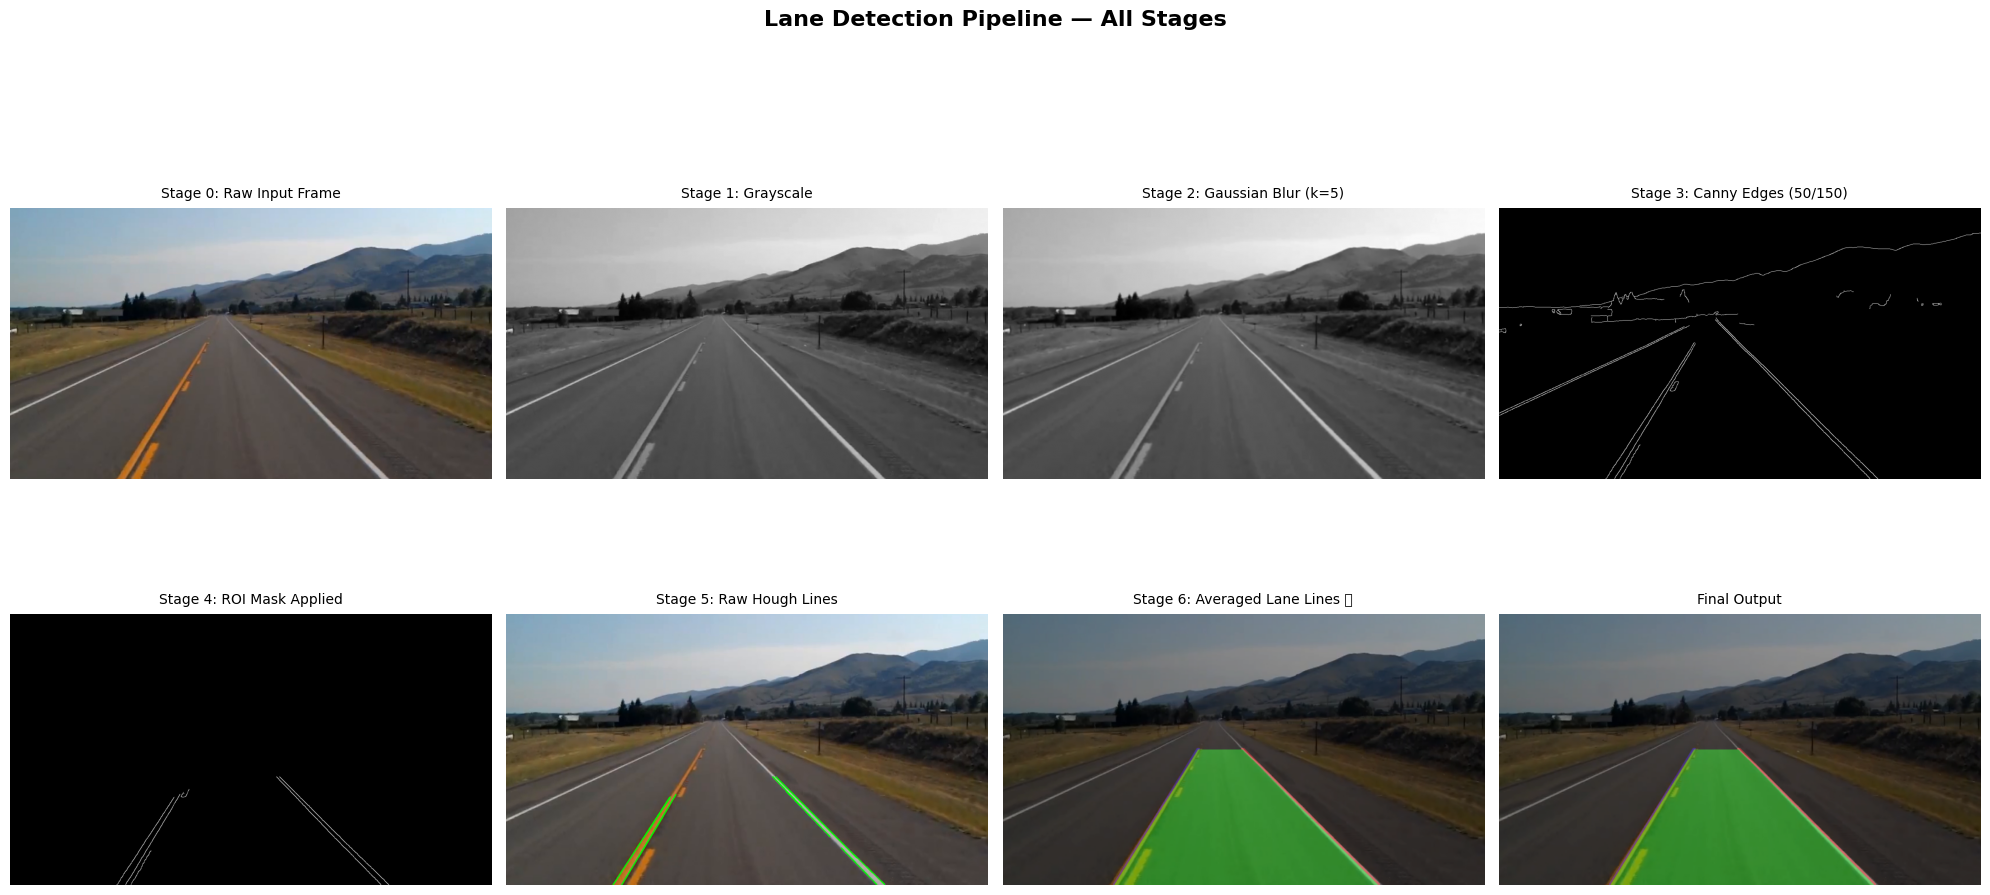

Saved: pipeline_visualisation.png — use this in your README!


In [12]:
# Grab a clean frame from the middle of the video for the visualisation
cap = cv2.VideoCapture('test_video.mp4')
cap.set(cv2.CAP_PROP_POS_FRAMES, 150)
ret, demo_frame = cap.read()
cap.release()

h, w = demo_frame.shape[:2]

# Run each stage
demo_gray    = apply_grayscale(demo_frame)
demo_blurred = apply_gaussian_blur(demo_gray)
demo_edges   = apply_canny(demo_blurred)
demo_masked, _ = apply_roi_mask(demo_edges, h, w)
demo_lines   = apply_hough_transform(demo_masked)
demo_hough   = draw_raw_hough_lines(cv2.cvtColor(demo_frame, cv2.COLOR_BGR2RGB), demo_lines)
demo_left, demo_right = average_lane_lines(demo_frame, demo_lines)
demo_result  = draw_lane_lines(demo_frame.copy(), demo_left, demo_right)

# Build the visualisation grid
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Lane Detection Pipeline — All Stages', fontsize=16, fontweight='bold', y=1.02)

stages = [
    (cv2.cvtColor(demo_frame, cv2.COLOR_BGR2RGB), 'Stage 0: Raw Input Frame', None),
    (demo_gray,                                    'Stage 1: Grayscale', 'gray'),
    (demo_blurred,                                 'Stage 2: Gaussian Blur (k=5)', 'gray'),
    (demo_edges,                                   'Stage 3: Canny Edges (50/150)', 'gray'),
    (demo_masked,                                  'Stage 4: ROI Mask Applied', 'gray'),
    (demo_hough,                                   'Stage 5: Raw Hough Lines', None),
    (cv2.cvtColor(demo_result, cv2.COLOR_BGR2RGB), 'Stage 6: Averaged Lane Lines ✅', None),
    (cv2.cvtColor(demo_result, cv2.COLOR_BGR2RGB), 'Final Output', None),
]

for ax, (img, title, cmap) in zip(axes.flatten(), stages):
    ax.imshow(img, cmap=cmap)
    ax.set_title(title, fontsize=10, pad=8)
    ax.axis('off')

plt.tight_layout()
plt.savefig('pipeline_visualisation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pipeline_visualisation.png — use this in your README!')